# Foundation models vs classical forecasting: a hands-on comparison

A hands-on walkthrough on real data no model could have memorized: UK half-hourly
electricity demand from 2026.

This compares **three things you would actually choose between**:

1. **TimesFM 2.5** (Google): a time-series foundation model
2. **Chronos-2** (Amazon): a foundation model from a different family, with a different API
3. **AutoETS / seasonal naive**: the classical stack a foundation model has to beat

**What this covers**

1. Getting a clean series, and the checks that must pass *before* the model call
2. Loading each model, with every config flag explained
3. One forecast from each, plotted against the truth
4. Metrics that are valid for this data: and one that usually is not
5. A rolling-origin evaluation, because one forecast proves nothing
6. **Two horizons**: day-ahead and week-ahead: because the winner changes between them

**Prerequisites**

```bash
pip install torch                     # match your accelerator: CPU / CUDA / Apple MPS
pip install -r requirements.txt
python3 datasets.py --keys uk_demand_30min   # caches the data locally, no API key
```

Run this notebook from the repository root so it can import `datasets.py` and
`prepare.py`. TimesFM and Chronos coexist in one environment; Toto and Moirai do not, which
is why the full study uses one virtualenv per family: see `envs/README.md`.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, str(Path.cwd()))
import datasets as ds
import prepare as P

print(f"python {sys.version.split()[0]} | numpy {np.__version__} | "
      f"pandas {pd.__version__} | torch {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()} | "
      f"CUDA available: {torch.cuda.is_available()}")

python 3.12.13 | numpy 2.2.6 | pandas 2.3.3 | torch 2.13.0
MPS available: True | CUDA available: False


## 1. The series

UK national electricity demand, half-hourly, published openly by NESO. The forecasting
task is the real one: **at midnight, predict the next 48 settlement periods.**

Why this series and not ETTh1 or a Monash set? TimesFM 2.5's model card declares its
pretraining corpus: GiftEvalPretrain, Wikimedia pageviews to Nov 2023, Google Trends to
end-2022. Anything public and old enough cannot distinguish forecasting skill from recall.
Every observation here is from 2025-2026, after all of those cutoffs, so *zero-shot* means
what it says.

In [2]:
KEY = "uk_demand_30min"
HORIZON = 48        # 48 half-hours = 24 hours ahead
CONTEXT = 512       # ~10.7 days of history fed to the model

prep = P.prepare(KEY)          # fetches from cache, cleans, and audits
spec = prep.spec
y = prep.values
idx = pd.DatetimeIndex(prep.frame["timestamp"])

print(f"{KEY}: {len(y):,} observations, {idx.min()} -> {idx.max()}")
print(f"unit {spec.unit} | frequency {spec.freq} | "
      f"daily season {spec.season} steps | weekly season {spec.season_long} steps")
print(f"range {y.min():,.0f} - {y.max():,.0f} {spec.unit}")

uk_demand_30min: 26,544 observations, 2025-01-01 00:00:00 -> 2026-07-07 23:30:00
unit MW | frequency 30min | daily season 48 steps | weekly season 336 steps
range 12,626 - 47,382 MW


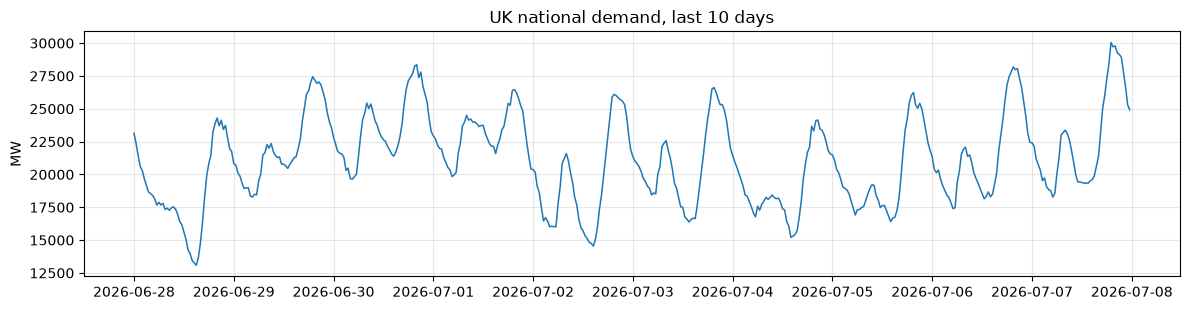

In [3]:
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.plot(idx[-480:], y[-480:], lw=1.1)
ax.set_title("UK national demand, last 10 days")
ax.set_ylabel(spec.unit)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. What must be true before you call the model

A foundation model takes a bare array of floats. No timestamps, no schema, **no
complaint**. That is exactly why it is easy to hand it something quietly wrong and get a
plausible forecast back.

`prepare.py` runs eleven checks. The five that matter most:

| check | why it bites |
|---|---|
| regular grid | the model indexes by **position**, so one missing step shifts every later point in "model time" and corrupts the periodicity |
| gap policy | interpolating a 3-step gap is fine; filling a 3-day outage teaches a trend that never happened |
| NaN policy | TimesFM needs a clean float array. Chronos tolerates NaN. Same data, different rules |
| who scales | TimesFM scales internally via `normalize_inputs`. A GBDT does not. Pre-scaling TimesFM is double work |
| is the metric valid | MAPE needs a ratio scale with a meaningful zero: it is meaningless for temperature in °C |

In [4]:
a = prep.audit
for k in ["rows_out", "duplicate_timestamps", "irregular_steps", "missing_on_grid",
          "interpolated", "longest_gap_steps", "declared_positive",
          "observed_nonpositive", "zero_frac", "ratio_scale",
          "seasonal_strength", "trend_strength", "spectral_entropy"]:
    print(f"  {k:24} {a.get(k)}")

print(f"\nblockers: {prep.blockers or 'none'}")
print(f"MAPE valid for this series? {prep.mape_valid}")
print(f"\nirregular steps are real here: {a['step_histogram']}")
print("  ^ the 1:30 entries are the clock-change days (46- and 50-period days),")
print("    which is a genuine irregular grid, not dirty data.")

prep.assert_ready_for("timesfm")   # raises if the series violates TimesFM's requirements
print("\nready for TimesFM")

  rows_out                 26544
  duplicate_timestamps     2
  irregular_steps          2
  missing_on_grid          4
  interpolated             4
  longest_gap_steps        2
  declared_positive        True
  observed_nonpositive     0
  zero_frac                0.0
  ratio_scale              True
  seasonal_strength        0.85
  trend_strength           0.884
  spectral_entropy         0.345

blockers: none
MAPE valid for this series? True

irregular steps are real here: {'0 days 00:30:00': 26537, '0 days 01:30:00': 2}
  ^ the 1:30 entries are the clock-change days (46- and 50-period days),
    which is a genuine irregular grid, not dirty data.

ready for TimesFM


## 3. Load and compile TimesFM 2.5

`compile()` is not optional and not cosmetic: it fixes the maximum context and horizon
the model will accept, so it belongs in your setup path, not your request path.

Every flag, and why it is set this way for electricity demand:

- `max_context` / `max_horizon`: upper bounds you must not exceed at call time. 2.5
  supports up to 16,384 context.
- `normalize_inputs=True`: **the model owns scaling.** Do not standardise beforehand.
- `use_continuous_quantile_head=True`: enables the optional 30M quantile head, so you get
  a distribution instead of a single line. Without this you cannot compute WQL or coverage.
- `force_flip_invariance=True`: stabilises behaviour under sign flips.
- `infer_is_positive=True`: demand cannot be negative. Only claim this when it is true;
  it would be wrong for temperature in °C or for returns.
- `fix_quantile_crossing=True`: enforces that the 10th percentile stays below the 90th.
  Quantile crossing is common and makes intervals nonsense.

One more difference from TimesFM 1.0/2.0 worth knowing: **2.5 dropped the frequency
indicator.** You no longer tell it "this is hourly"; it infers periodicity from the context.
That is also why context length matters: it must cover several full seasonal cycles.

In [5]:
import time

import timesfm

torch.set_float32_matmul_precision("high")

t0 = time.perf_counter()
model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch")
model.compile(timesfm.ForecastConfig(
    max_context=CONTEXT,
    max_horizon=HORIZON,
    normalize_inputs=True,
    use_continuous_quantile_head=True,
    force_flip_invariance=True,
    infer_is_positive=True,
    fix_quantile_crossing=True,
))
print(f"loaded + compiled in {time.perf_counter() - t0:.1f}s")

.venv-core/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded + compiled in 3.2s


## 4. One forecast from each model

Hold out the final 48 periods, feed everything before them to both models, and compare.

The two APIs differ in ways worth knowing before you wire either into a pipeline:

- **TimesFM** takes a *list of 1-D arrays* and returns `point_forecast` plus
  `quantile_forecast` of shape `(n_series, horizon, 10)`, where index **0 is the mean** and
  **1-9 are the deciles**. Getting that indexing wrong is the most common mistake with this API.
- **Chronos-2** takes a *3-D tensor* `(batch, variates, history)`: it is multivariate-native,
  which TimesFM 2.5 is not: and returns 21 quantile levels, of which we take the deciles.

Neither wants pre-scaled input: both normalize internally.


In [6]:
split = len(y) - HORIZON
context = y[split - CONTEXT:split]
actual = y[split:]

t0 = time.perf_counter()
point, quant = model.forecast(horizon=HORIZON, inputs=[context])
elapsed = time.perf_counter() - t0

point, quant = np.asarray(point), np.asarray(quant)
print(f"point_forecast    {point.shape}")
print(f"quantile_forecast {quant.shape}   (index 0 = mean, 1..9 = deciles 0.1..0.9)")
print(f"{elapsed * 1000:.0f} ms for a 48-step forecast")

fc = point[0]
deciles = quant[0][:, 1:10]      # (48, 9)
lo, med, hi = deciles[:, 0], deciles[:, 4], deciles[:, 8]

point_forecast    (1, 48)
quantile_forecast (1, 48, 10)   (index 0 = mean, 1..9 = deciles 0.1..0.9)
825 ms for a 48-step forecast


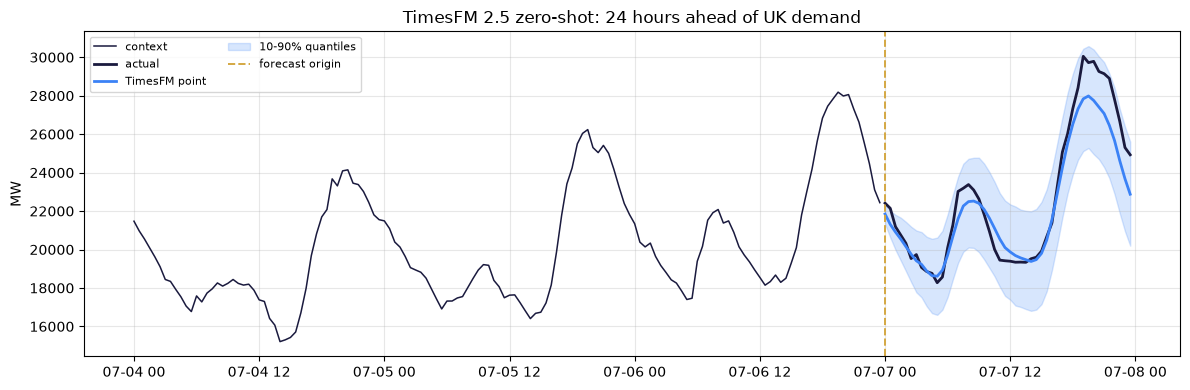

In [7]:
hist = 144   # show 3 days of context for scale
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(idx[split - hist:split], y[split - hist:split], lw=1.1,
        color="#1A1A3E", label="context")
ax.plot(idx[split:], actual, lw=2.0, color="#1A1A3E", label="actual")
ax.plot(idx[split:], fc, lw=2.0, color="#3B82F6", label="TimesFM point")
ax.fill_between(idx[split:], lo, hi, color="#3B82F6", alpha=0.20,
                label="10-90% quantiles")
ax.axvline(idx[split], color="#D4A843", lw=1.4, ls="--", label="forecast origin")
ax.set_title("TimesFM 2.5 zero-shot: 24 hours ahead of UK demand")
ax.set_ylabel(spec.unit)
ax.legend(loc="upper left", fontsize=8, ncols=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Chronos-2; a foundation model from a different family, in the same environment.
# (Toto and Moirai would NOT load here: both pin numpy back to 1.26 and NumPy 2.0 changed
#  the C ABI. That is why the full study runs one virtualenv per family.)
from chronos import BaseChronosPipeline

t0 = time.time()
chronos = BaseChronosPipeline.from_pretrained("amazon/chronos-2")
print(f"Chronos-2 loaded in {time.time() - t0:.1f}s")

# Chronos exposes 21 quantile levels; these indices are the deciles 0.1 .. 0.9
CHRONOS_DECILE_IDX = [2, 4, 6, 8, 10, 12, 14, 16, 18]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 170/170 [00:00<00:00, 7433.69it/s]

Chronos-2 loaded in 1.6s


In [9]:
def chronos_forecast(ctx_arr: np.ndarray, horizon: int):
    """Chronos-2 wants (batch, variates, history); 3-D even for a univariate series."""
    x = torch.tensor(ctx_arr.astype("float32"))[None, None, :]
    pred = chronos.predict(x, prediction_length=horizon)
    a = np.asarray(pred[0])                    # (variates=1, 21, horizon)
    q = a[0][CHRONOS_DECILE_IDX, :].T          # (horizon, 9)
    return q[:, 4], q                          # median as the point forecast


chr_point, chr_q = chronos_forecast(context, HORIZON)
print("Chronos-2 point:", chr_point.shape, " deciles:", chr_q.shape)

Chronos-2 point: (48,)  deciles: (48, 9)


## 4b. And the classical comparator

A foundation model has to beat the stack it replaces, not a straw man. Two baselines:

- **`seasonal_naive`**: yesterday's same half-hour. On a load curve this is the *right*
  naive, and it is the denominator MASE is scaled against, so it scores exactly 1.0 by
  construction.
- **AutoETS**: the classical workhorse. Note it is not built for a seasonal period of 48;
  that is precisely why high-frequency load forecasting moved to MSTL and TBATS years ago.
  Including it as the only classical comparator is how benchmarks overstate a foundation
  model's gain.

In [10]:
import models as M

season = spec.season
snaive = np.resize(context[-season:], HORIZON)

task = M.Task(y=y[:split], ctx_index=idx[:split],
              fut_index=idx[split:split + HORIZON], horizon=HORIZON)
autoets = M.StatsForecastModel("AutoETS").batch([task], spec)[0]

# MASE denominator: in-sample MAE of the seasonal naive on THIS context; identical for
# every model, which is the only way the numbers below are comparable.
den = np.mean(np.abs(context[season:] - context[:-season]))

for name, f in [("TimesFM 2.5", fc), ("Chronos-2", chr_point),
                ("AutoETS", autoets.point), ("seasonal_naive", snaive)]:
    print(f"  {name:16} MASE {np.mean(np.abs(actual - f)) / den:.4f}")

  TimesFM 2.5      MASE 0.3574
  Chronos-2        MASE 0.6053
  AutoETS          MASE 1.4735
  seasonal_naive   MASE 0.4908


## 5. Metrics that are valid for this data

- **MASE**: mean absolute error divided by the *in-sample* MAE of the seasonal naive on
  the same context. Below 1.0 means you beat that naive. Scale-free, so it works on any
  series, which is why it is the primary metric.
- **MAPE**: what utilities report. Only valid on a **ratio scale with a meaningful zero**.
  Fine for demand; arithmetically meaningless for temperature in °C or for returns. Always
  check before you print it.
- **WQL**: weighted quantile loss over the nine deciles: does the whole distribution fit,
  not just the middle line.
- **Coverage**: how often the truth fell inside the nominal 10-90% band. Should be 80%.
  This is a calibration check, not an accuracy score.

In [11]:
QLEVELS = np.arange(1, 10) / 10.0


def mase(y_true, f, ctx, season):
    denom = np.mean(np.abs(ctx[season:] - ctx[:-season]))
    return np.mean(np.abs(y_true - f)) / denom


def mape(y_true, f):
    return np.mean(np.abs((y_true - f) / y_true)) * 100


def wql(y_true, q):
    """q: (h, 9) aligned to QLEVELS. Doubled pinball loss, normalized by sum|y|."""
    total = sum(2.0 * np.sum(np.where(y_true >= q[:, k], lv * (y_true - q[:, k]),
                                      (1 - lv) * (q[:, k] - y_true)))
                for k, lv in enumerate(QLEVELS))
    return total / (len(QLEVELS) * np.sum(np.abs(y_true)))


def coverage(y_true, lo_, hi_):
    return np.mean((y_true >= lo_) & (y_true <= hi_)) * 100


# the baseline you must beat: yesterday, same half-hour
naive = context[-spec.season:][:HORIZON]

print(f"{'':<16}{'MASE':>8}{'MAPE %':>9}{'WQL':>9}{'cover80':>9}")
print(f"{'TimesFM 2.5':<16}{mase(actual, fc, context, spec.season):>8.3f}"
      f"{mape(actual, fc):>9.2f}{wql(actual, deciles):>9.4f}"
      f"{coverage(actual, lo, hi):>9.1f}")
print(f"{'seasonal naive':<16}{mase(actual, naive, context, spec.season):>8.3f}"
      f"{mape(actual, naive):>9.2f}{'-':>9}{'-':>9}")

                    MASE   MAPE %      WQL  cover80
TimesFM 2.5        0.357     3.21   0.0302     95.8
seasonal naive     0.491     4.69        -        -


## 6. One forecast proves nothing

A single origin is a coin flip. On this series an 8-origin sample says TimesFM *loses* to
the weekly lag; at 129 origins it wins by 28%. Eight days is not an evaluation.

So: roll the origin forward one day at a time, forecast each day, and look at the
distribution. Two baselines, because picking the wrong naive is how people manufacture a
victory: `seasonal_naive` is right for a load curve, `naive_last` is right for a random
walk.

In [12]:
N_ORIGINS = 14
origins = [len(y) - HORIZON - k * spec.season for k in range(N_ORIGINS)][::-1]

contexts = [y[o - CONTEXT:o] for o in origins]
targets = [y[o:o + HORIZON] for o in origins]

t0 = time.perf_counter()
pts, qs = model.forecast(horizon=HORIZON, inputs=contexts)   # batched: one call
batch_time = time.perf_counter() - t0
pts, qs = np.asarray(pts), np.asarray(qs)
print(f"{N_ORIGINS} forecasts in {batch_time:.2f}s "
      f"({batch_time / N_ORIGINS * 1000:.0f} ms each, batched)")

rows = []
for i, o in enumerate(origins):
    ctx, act = contexts[i], targets[i]
    dec = qs[i][:, 1:10]
    rows.append({"date": idx[o].date(),
                 "timesfm": mase(act, pts[i], ctx, spec.season),
                 "seasonal_naive": mase(act, ctx[-spec.season:][:HORIZON], ctx,
                                        spec.season),
                 "naive_last": mase(act, np.repeat(ctx[-1], HORIZON), ctx, spec.season),
                 "timesfm_mape": mape(act, pts[i]),
                 "timesfm_wql": wql(act, dec),
                 "cover80": coverage(act, dec[:, 0], dec[:, 8])})

res = pd.DataFrame(rows)
res.round(3)

14 forecasts in 8.36s (597 ms each, batched)


,date,timesfm,seasonal_naive,naive_last,timesfm_mape,timesfm_wql,cover80
0,2026-06-24,0.474,0.671,1.667,2.882,0.023,87.500
1,2026-06-25,0.563,0.362,1.886,3.352,0.024,83.333
2,2026-06-26,0.990,0.947,1.734,4.875,0.038,60.417
3,2026-06-27,1.199,3.368,3.825,8.254,0.060,54.167
4,2026-06-28,1.499,1.489,2.848,14.235,0.100,43.750
5,2026-06-29,0.655,2.078,1.228,5.299,0.041,75.000
6,2026-06-30,0.459,0.692,1.018,3.969,0.033,68.750
7,2026-07-01,0.626,0.461,0.693,5.534,0.044,68.750
8,2026-07-02,1.032,1.941,1.628,12.232,0.086,62.500
9,2026-07-03,0.471,0.673,1.275,5.141,0.037,100.000


In [13]:
print("MASE over", N_ORIGINS, "day-ahead origins (lower is better, 1.0 = the naive)\n")
summary = res[["timesfm", "seasonal_naive", "naive_last"]].agg(
    ["mean", "median", "max"]).round(3)
print(summary.to_string())

beat_sn = (res.timesfm < res.seasonal_naive).mean() * 100
beat_nl = (res.timesfm < res.naive_last).mean() * 100
gain = (1 - res.timesfm.mean() / res.seasonal_naive.mean()) * 100
print(f"\nTimesFM beat seasonal_naive on {beat_sn:.0f}% of days, "
      f"naive_last on {beat_nl:.0f}%")
print(f"mean MASE improvement vs seasonal_naive: {gain:.1f}%")
print(f"mean 80% interval coverage: {res.cover80.mean():.1f}% (nominal 80)")

MASE over 14 day-ahead origins (lower is better, 1.0 = the naive)

        timesfm  seasonal_naive  naive_last
mean      0.676           1.078       1.666
median    0.580           0.711       1.457
max       1.499           3.368       3.825

TimesFM beat seasonal_naive on 71% of days, naive_last on 100%
mean MASE improvement vs seasonal_naive: 37.2%
mean 80% interval coverage: 78.6% (nominal 80)


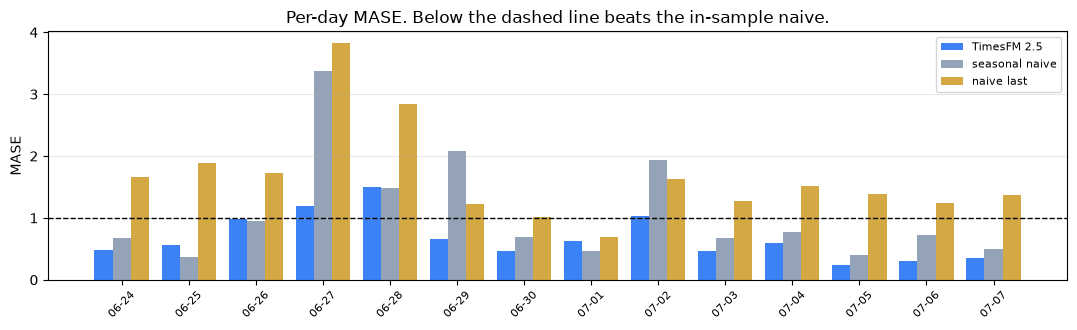

In [14]:
fig, ax = plt.subplots(figsize=(11, 3.4))
w = 0.27
pos = np.arange(len(res))
ax.bar(pos - w, res.timesfm, w, label="TimesFM 2.5", color="#3B82F6")
ax.bar(pos, res.seasonal_naive, w, label="seasonal naive", color="#94A3B8")
ax.bar(pos + w, res.naive_last, w, label="naive last", color="#D4A843")
ax.axhline(1.0, color="black", lw=1, ls="--")
ax.set_xticks(pos)
ax.set_xticklabels([str(d)[5:] for d in res.date], rotation=45, fontsize=8)
ax.set_ylabel("MASE")
ax.set_title("Per-day MASE. Below the dashed line beats the in-sample naive.")
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 7. Things that will bite you

From building the full ten-dataset study in this repo:

1. **It has no calendar.** TimesFM sees numbers. On UK bank holidays it lost to
   yesterday-repeat, because it extrapolates the weekly rhythm and a holiday breaks it.
   Holiday and weather knowledge goes back in through covariates (XReg), not hope.
2. **Long context buys tail robustness, not accuracy.** Going 512 → 8192 improved mean
   MAPE by about 5% but cut the p90 from 12.0 to 10.3. Latency was flat, because the model
   patches its input rather than attending over raw points.
3. **Sampling-based models need an explicit seed.** Toto draws Monte Carlo sample
   paths, and nothing seeds them for you; set `torch.manual_seed` yourself or two
   "identical" runs will not match.
4. **Quantiles are usable but not calibrated.** Coverage of the nominal 80% band ran
   74-89% across series here. If a decision hangs on the interval, conformalize it on a
   holdout.
5. **Pick the right naive.** On a random walk, `naive_last` matched all three foundation
   models. On spiky air quality it beat them. On zero-mean noise the context mean is
   optimal and the *seasonal* naive is actively harmful.
6. **Check MAPE is defined before printing it.** It is invalid on five of the ten series in
   this repo.

## Where to go next

- `python3 prepare.py`: the eleven pre-call checks across all ten datasets
- `python3 benchmark.py --origins 16`: the full bake-off: TimesFM vs Chronos-2 vs
  Chronos-Bolt vs AutoETS/AutoTheta/MSTL vs a GBDT vs four naive baselines
- `python3 benchmark.py --multivariate`: Chronos-2 forecasting BOOM telemetry variates
  jointly vs one at a time (TimesFM 2.5 cannot do this; covariates go through XReg)
- `RESEARCH-NOTES.md`: the measured structure ladder for all ten series, and which
  competing models could not be installed alongside TimesFM

## 8. The horizon changes the answer

Everything above is a **day-ahead** forecast. That is one point on a curve, and nearly every
published benchmark reports exactly one point.

In the full ten-dataset study, the winner changes between horizons on the *same data*. On
Bangkok air quality a one-line baseline beats every foundation model at 1 day, and loses to
them at 7, 14 and 30 days: because persistence does not degrade gracefully over a week, it
collapses.

So re-run the comparison at a week-ahead horizon and watch the ordering move.

In [15]:
def compare_at(horizon: int, n_origins: int = 6):
    """Same models, same origins, one knob changed: the horizon."""
    # TimesFM fixes max_horizon at compile time, so a longer horizon needs a recompile.
    model.compile(timesfm.ForecastConfig(
        max_context=CONTEXT, max_horizon=horizon, normalize_inputs=True,
        use_continuous_quantile_head=True, force_flip_invariance=True,
        infer_is_positive=True, fix_quantile_crossing=True))

    origins = np.linspace(CONTEXT, len(y) - horizon, n_origins, dtype=int)
    out = {}
    for name in ["TimesFM 2.5", "Chronos-2", "AutoETS", "seasonal_naive"]:
        errs = []
        for o in origins:
            c, tgt = y[o - CONTEXT:o], y[o:o + horizon]
            d = np.mean(np.abs(c[season:] - c[:-season]))
            if name == "TimesFM 2.5":
                f = np.asarray(model.forecast(horizon=horizon, inputs=[c])[0])[0]
            elif name == "Chronos-2":
                f, _ = chronos_forecast(c, horizon)
            elif name == "AutoETS":
                t = M.Task(y=y[:o], ctx_index=idx[:o],
                           fut_index=idx[o:o + horizon], horizon=horizon)
                f = M.StatsForecastModel("AutoETS").batch([t], spec)[0].point
            else:
                f = np.resize(c[-season:], horizon)
            errs.append(np.mean(np.abs(tgt - f)) / d)
        out[name] = float(np.mean(errs))
    return out


for h, label in [(48, "1 day "), (336, "7 days")]:
    r = compare_at(h)
    best = min(r, key=r.get)
    print(f"{label}  " + "   ".join(f"{k} {v:.3f}" for k, v in r.items()) + f"   -> {best}")

1 day   TimesFM 2.5 0.486   Chronos-2 0.620   AutoETS 2.699   seasonal_naive 0.780   -> TimesFM 2.5


7 days  TimesFM 2.5 0.890   Chronos-2 0.900   AutoETS 2.440   seasonal_naive 1.145   -> TimesFM 2.5
